<a href="https://colab.research.google.com/github/20xygen/ML-Image-Compression/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Image Compression

## Prepare Data

In [ ]:
import kagglehub
import os
from pathlib import Path
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
import shutil

In [ ]:
!pip install -q kagglehub

path = kagglehub.dataset_download("hsankesara/flickr-image-dataset")
path

100%|██████████| 8.16G/8.16G [01:17<00:00, 113MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1'

In [ ]:
dataset_filename = os.listdir(path)[0]
dataset_filename

'flickr30k_images'

In [ ]:
dataset_path = os.path.join(path, dataset_filename)
os.listdir(dataset_path)

['flickr30k_images', 'results.csv']

In [ ]:
captions = os.path.join(dataset_path, 'results.csv')
df_captions = pd.read_csv(captions, sep='|')
df_captions

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .
...,...,...,...
158910,998845445.jpg,0,A man in shorts and a Hawaiian shirt leans ov...
158911,998845445.jpg,1,"A young man hanging over the side of a boat ,..."
158912,998845445.jpg,2,A man is leaning off of the side of a blue an...
158913,998845445.jpg,3,"A man riding a small boat in a harbor , with ..."


Sure. This is a image-to-caption dataset.

In [ ]:
dataset_images_directory = os.path.join(dataset_path, 'flickr30k_images')
os.listdir(dataset_images_directory)[:10]

['2330069984.jpg',
 '397547349.jpg',
 '1679565118.jpg',
 '1042359076.jpg',
 '4749605645.jpg',
 '2789648482.jpg',
 '13691837.jpg',
 '2978810122.jpg',
 '446714977.jpg',
 '531347711.jpg']

In [ ]:
len(os.listdir(dataset_images_directory))

31785

In [ ]:
image_files = os.listdir(dataset_images_directory)
metadata_list = []

for filename in tqdm(image_files):
    image_file = os.path.join(dataset_images_directory, filename)
    try:
        with Image.open(image_file) as img:
            width, height = img.size
            metadata_list.append({
                'filename': filename,
                'width': width,
                'height': height,
                'size_pixels': width * height,
                'format': img.format,
                'mode': img.mode
            })
    except Exception as e:
        print(e)

  0%|          | 0/31785 [00:00<?, ?it/s]

[Errno 21] Is a directory: '/root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/flickr30k_images/flickr30k_images'
cannot identify image file '/root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/flickr30k_images/results.csv'


In [ ]:
df_metadata = pd.DataFrame(metadata_list)
df_metadata

,filename,width,height,size_pixels,format,mode
0,2330069984.jpg,500,375,187500,JPEG,RGB
1,397547349.jpg,475,500,237500,JPEG,RGB
2,1679565118.jpg,500,375,187500,JPEG,RGB
3,1042359076.jpg,500,333,166500,JPEG,RGB
4,4749605645.jpg,500,388,194000,JPEG,RGB
...,...,...,...,...,...,...
31778,1295698260.jpg,257,500,128500,JPEG,RGB
31779,416272701.jpg,333,500,166500,JPEG,RGB
31780,3646820231.jpg,500,253,126500,JPEG,RGB
31781,6681702307.jpg,500,333,166500,JPEG,RGB


In [ ]:
df_metadata['format'].unique(), df_metadata['mode'].unique()

(array(['JPEG'], dtype=object), array(['RGB'], dtype=object))

In [ ]:
df_metadata = df_metadata.drop(columns=['format', 'mode'])
df_metadata

,filename,width,height,size_pixels
0,2330069984.jpg,500,375,187500
1,397547349.jpg,475,500,237500
2,1679565118.jpg,500,375,187500
3,1042359076.jpg,500,333,166500
4,4749605645.jpg,500,388,194000
...,...,...,...,...
31778,1295698260.jpg,257,500,128500
31779,416272701.jpg,333,500,166500
31780,3646820231.jpg,500,253,126500
31781,6681702307.jpg,500,333,166500


In [ ]:
df_metadata.describe()

,width,height,size_pixels
count,31783.000000,31783.000000,31783.000000
mean,459.607148,395.131485,177466.896454
std,67.482044,74.361142,20828.436644
min,164.000000,112.000000,43200.000000
25%,395.000000,333.000000,166500.000000
50%,500.000000,375.000000,167500.000000
75%,500.000000,500.000000,187500.000000
max,500.000000,500.000000,250000.000000


In [ ]:
mode_width = df_metadata["width"].mode()[0]
df_metadata[df_metadata["width"] == mode_width].describe()

,width,height,size_pixels
count,22756.0,22756.000000,22756.000000
mean,500.0,354.882580,177441.290209
std,0.0,41.984214,20992.107068
min,500.0,112.000000,56000.000000
25%,500.0,333.000000,166500.000000
50%,500.0,334.000000,167000.000000
75%,500.0,375.000000,187500.000000
max,500.0,500.000000,250000.000000


In [ ]:
df_metadata[df_metadata["width"] == mode_width]["height"].value_counts()

,count
height,
333,6421
375,6247
334,1415
332,1288
500,540
...,...
226,1
220,1
204,1


Oh...

In [ ]:
df_metadata["aspect_ratio"] = df_metadata["width"] / df_metadata["height"]
df_metadata.describe()

,width,height,size_pixels,aspect_ratio
count,31783.000000,31783.000000,31783.000000,31783.000000
mean,459.607148,395.131485,177466.896454,1.228410
std,67.482044,74.361142,20828.436644,0.354524
min,164.000000,112.000000,43200.000000,0.328000
25%,395.000000,333.000000,166500.000000,0.796000
50%,500.000000,375.000000,167500.000000,1.333333
75%,500.000000,500.000000,187500.000000,1.501502
max,500.000000,500.000000,250000.000000,4.464286


In [ ]:
width, height = 400, 320
df_eligible = df_metadata[(df_metadata['width'] >= width) & (df_metadata['height'] >= height)].copy()
df_eligible.shape[0]

22168

Ok, that's for sure enough for me.

In [ ]:
cropped_dir = "/content/cropped"
os.makedirs(cropped_dir, exist_ok=True)

In [ ]:
# for filename in tqdm(df_eligible['filename']):
#     img_path = os.path.join(dataset_images_directory, filename)
#     with Image.open(img_path) as img:
#         img = img.convert('RGB')
#         current_width, current_height = img.size
#         left = (current_width - width) // 2
#         top = (current_height - height) // 2
#         right = left + width
#         bottom = top + height
#         cropped = img.crop((left, top, right, bottom))
#         cropped.save(os.path.join(cropped_dir, filename.replace('.jpg', '_cropped.png')))

In [ ]:
# sum(
#     os.path.getsize(os.path.join(cropped_dir, f))
#     for f in os.listdir(cropped_dir)
#     if os.path.isfile(os.path.join(cropped_dir, f))
# ) / 1024 / 1024

That was very time consuming. Let's save some time for the future me and zip the images.

In [ ]:
zip_filename = "cropped_flickr30k.zip"
zip_path = f'/content/{zip_filename}'

In [ ]:
# !zip -r -q {zip_path} {cropped_dir}

5 GB of data is too much for working in the Colab.

In [ ]:
small_dir = '/content/cropped_small'
small_size = 2000

In [ ]:
# import random
# import shutil

# os.makedirs(small_dir, exist_ok=True)

# cropped_files = [f for f in os.listdir(cropped_dir) if f.endswith('.png')]
# subset_files = random.sample(cropped_files, small_size)

# for filename in tqdm(subset_files):
#     src = os.path.join(cropped_dir, filename)
#     dst = os.path.join(small_dir, filename)
#     shutil.copyfile(src, dst)

In [ ]:
zip_small_filename = "cropped_flickr30k_small.zip"
zip_small_path = f'/content/{zip_small_filename}'

In [ ]:
# !zip -r -q {zip_small_path} {small_dir}

Loading part is following.

In [ ]:
def load_data(use_small_dataset: bool = True):
    zip_load_path = zip_small_path if use_small_dataset else zip_path
    directory_name = small_dir if use_small_dataset else cropped_dir
    source = f"/content{directory_name}"
    destination = "/content/data"

    shutil.unpack_archive(zip_load_path, "/content", "zip")
    os.makedirs(destination, exist_ok=True)
    num_size = len(str(len(os.listdir(source))-1))
    for i, name in enumerate(tqdm(os.listdir(source))):
        shutil.move(os.path.join(source, name), os.path.join(destination, f'{"0"*(num_size-len(str(i)))}{i}.png'))
    shutil.rmtree("/content/content")

In [ ]:
load_data()

  0%|          | 0/2000 [00:00<?, ?it/s]

## Image Compression

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import Dataset
from PIL import Image
import os
import torch.nn as nn
from torch.utils.data import random_split

In [ ]:
!pip install optuna optuna-dashboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 11.7 MB/s eta 0:00:00


In [ ]:
import optuna
from optuna.trial import TrialState
from optuna.pruners import MedianPruner

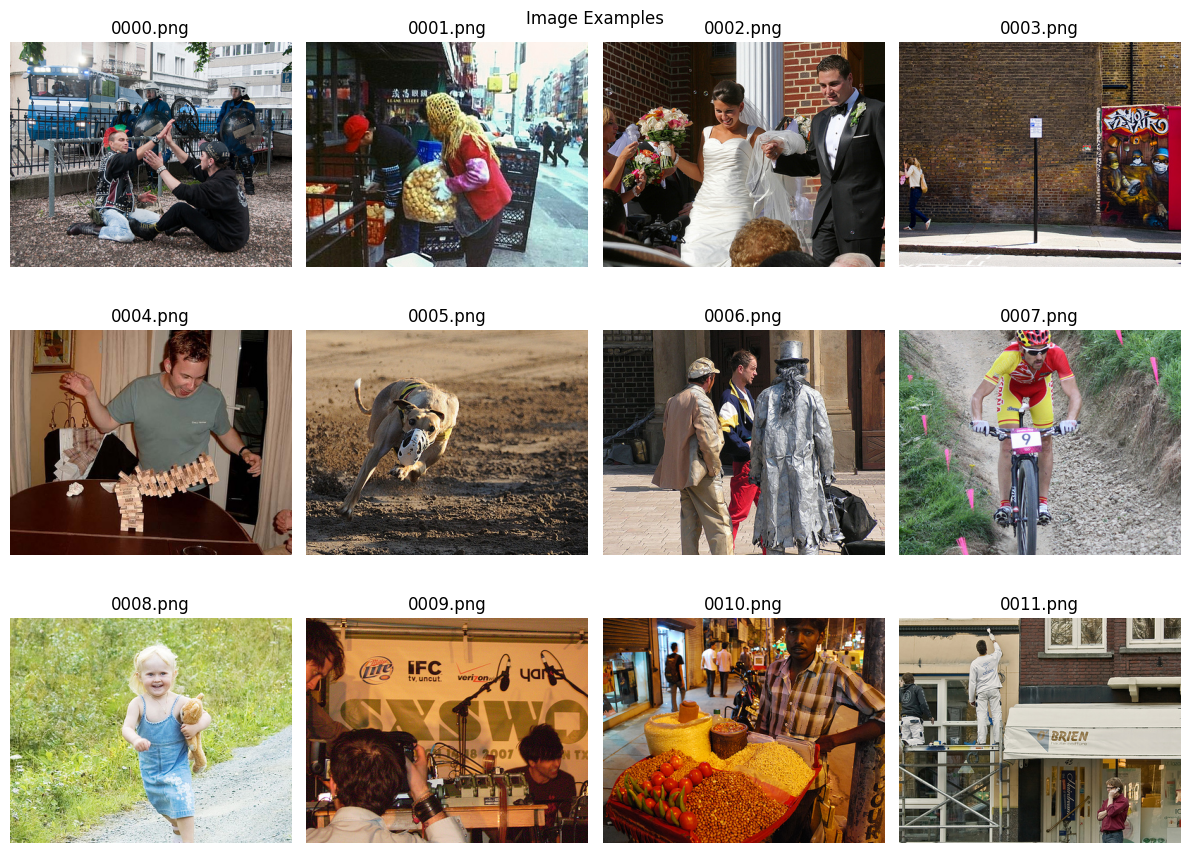

In [ ]:
data_path = "/content/data"
examples = sorted(os.listdir(data_path))[:12]

images = []
titles = []
for filename in examples:
    path = os.path.join(data_path, filename)
    img = Image.open(path).convert('RGB')
    images.append(img)
    titles.append(filename)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for i in range(12):
    axes[i].imshow(images[i])
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Image Examples")
plt.show()


In [ ]:
transform = transforms.Compose([
    # transforms.Resize(256),
    # transforms.CenterCrop(256),
    transforms.ToTensor(),
])

The `datasets.ImageFolder` taking the directory with subdirectories for each class. Since we have no classes there are two possible solutions:

1. Create one dummy folder for the whole dataset.
2. Make a subdirectory-class for every single image.
3. Do not use `ImageFolder`.

I have chosen the third one.

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.image_files = os.listdir(folder_path)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image


dataset = CustomImageDataset(data_path, transform=transform)

Filally, it is the time to create a model. What do we need from it? It should basically compress the image.

One image roughly consumes $3 \cdot Height \cdot Width$ bytes (one byte of information for every color for each pixel. In our case it is...

In [ ]:
3 * 420 * 300

378000

`PyTorch` uses `float32` as a base type for every parameter. `float32`obviously is 4 bytes.

In [ ]:
3 * 420 * 300 / 4

94500.0

So we want our model to have not more than `90'000` parameters on its bottle-neck. We have ignored come negligible (metadata) and important (png loss-less compression) to keep it simple, therefore we wanna have a decent gap between the goal and the results.

Let's start with a simple convolution.

In [ ]:
class SimpleCNNAutoencoder(nn.Module):
    def __init__(self):
        super(SimpleCNNAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # -> 16 x 200 x 160
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # -> 32 x 100 x 80
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> 64 x 50 x 40
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # -> 128 x 25 x 20
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 64 x 50 x 40
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 32 x 100 x 80
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 16 x 200 x 160
            nn.ReLU(),

            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 3 x 400 x 320
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def compress(self, image):
        return self.encoder(image)

    def decompress(self, embedding):
        return self.decoder(embedding)

According to the implementation, this model has `64000` values on it's bottle-neck.

In [ ]:
def torch_train_test_split(dataset, shares = [.8, .1, .1], **params):
    if sum(shares) == 1:
        total_size = len(dataset)
        lengths = [int(share * total_size) for share in shares]
        lengths[-1] = total_size - sum(lengths[:-1])
        return random_split(dataset, lengths, **params)
    else:
        return random_split(dataset, shares, **params)

RANDOM_SEED = 42
generator = torch.Generator().manual_seed(RANDOM_SEED)

train_dataset, val_dataset, test_dataset = torch_train_test_split(dataset, generator=generator)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

We want to see the output to be the most similar to the input which is equal to target. Therefore, I will use MSE. And of course Adam is the good choice in optimization MSE of NN.

We are ready to train!

In [ ]:
experiments = dict()

In [ ]:
def train(model, optimizer, criterion = nn.MSELoss(), max_epochs = 150, **params):
    max_epochs = 150
    model.train()

    history = []
    experiment = {
        "history": history,
        "max_epochs": max_epochs,
        "model": model,
    }
    experiment.update(params)

    loss_cycle = []
    for epoch in tqdm(range(max_epochs)):
        model.train()
        train_loss = 0.0
        for images in train_loader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images in val_loader:
                images = images.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, images).item()

        history.append({
            "epoch": epoch,
            "epoch_train_loss": train_loss / len(train_loader),
            "epoch_val_loss": val_loss / len(val_loader),
        })

        loss_cycle.append(val_loss / len(val_loader))
        if len(loss_cycle) > 4:
            loss_cycle.pop(0)

        if len(loss_cycle) == 4 and all([loss_cycle[i] - loss_cycle[i+1] < 1e-6 for i in range(len(loss_cycle)-1)]):
            break

    return experiment

In [ ]:
model = SimpleCNNAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

experiment = train(model, optimizer, criterion, model_name="SimpleCNNAutoencoder", hyperparameters={"lr": 1e-3, "weight_decay": 1e-5})

In [ ]:
experiments[experiment['model_name']] = experiment
torch.save(model.state_dict(), f"/content/{experiment['model_name']}.pth")

In [ ]:
def draw_loss(experiment):
    train_losses = []
    val_losses = []

    for entry in experiment['history']:
        train_losses.append(entry["epoch_train_loss"])
        val_losses.append(entry["epoch_val_loss"])

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss", color='blue')
    plt.plot(range(1, len(train_losses)+1), val_losses, label="Validation Loss", linestyle='--', color='orange')

    plt.title(f"Losses of {experiment['model_name']}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

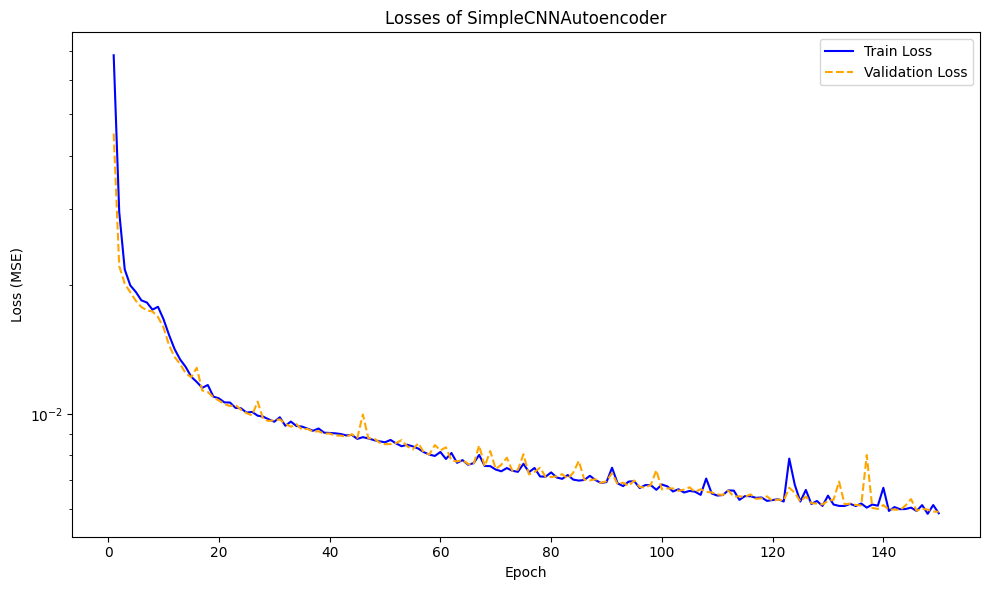

In [ ]:
draw_loss(experiment)

In [ ]:
def draw_images(experiment, data_loader):
    model = experiment['model']
    model.eval()

    images = next(iter(data_loader)).to(device)

    with torch.no_grad():
        reconstructions = model(images)

    originals = images.cpu()
    recons = reconstructions.cpu()

    originals = originals[:3]
    recons = recons[:3]

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    for i in range(3):
        img_orig = originals[i].permute(1, 2, 0).numpy()
        axes[0, i].imshow(img_orig)
        axes[0, i].set_title(f"Original {i+1}")
        axes[0, i].axis('off')

        img_recon = recons[i].permute(1, 2, 0).numpy()
        axes[1, i].imshow(img_recon)
        axes[1, i].set_title(f"Reconstructed {i+1}")
        axes[1, i].axis('off')

    plt.suptitle(f"Original vs Reconstructed ({experiment['model_name']})")
    plt.tight_layout()
    plt.show()

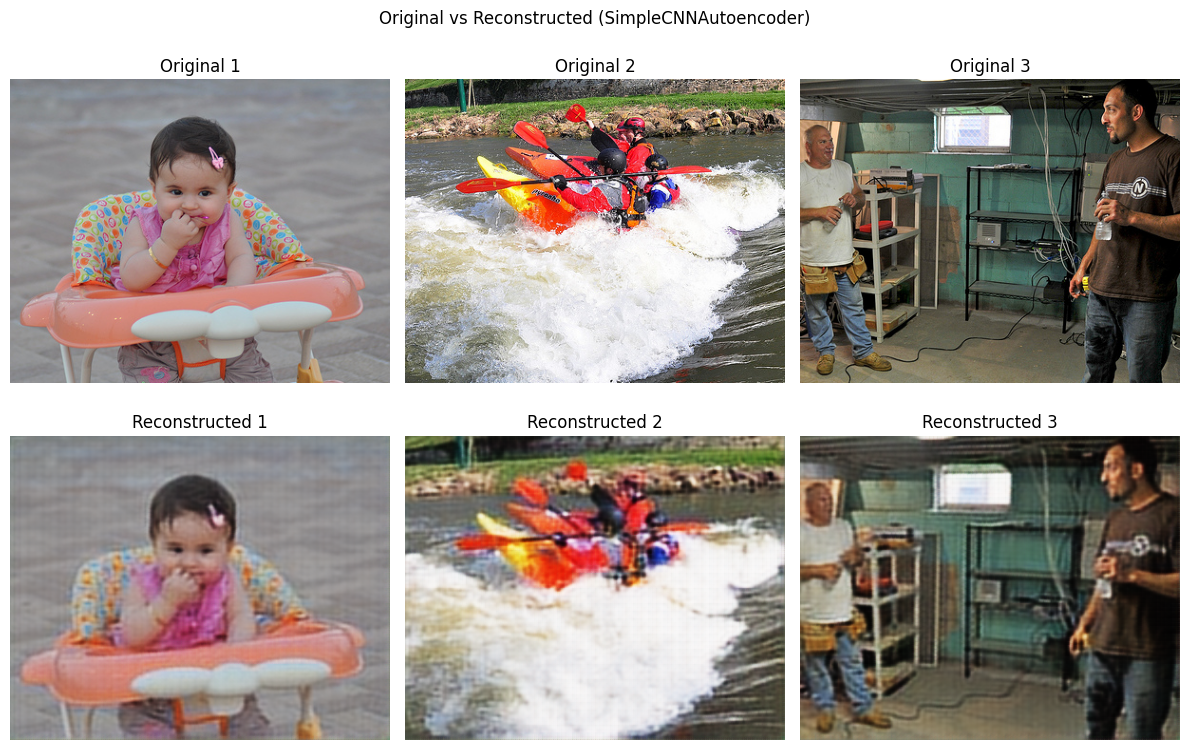

In [ ]:
draw_images(experiment, val_loader)

Hooray!

Since our simple model does not have hyperparameters we will optimize these for the optimizer. I will use Optuna.

In [ ]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    model = SimpleCNNAutoencoder().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    avg_val_loss = 0.0
    for epoch in range(20):
        model.train()
        train_loss = 0.0
        for images in train_loader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images in val_loader:
                images = images.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, images).item()

        avg_val_loss = val_loss / len(val_loader)

        trial.report(avg_val_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return avg_val_loss

In [ ]:
study = optuna.create_study(
    direction="minimize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10, interval_steps=1)
)

study.optimize(objective, n_trials=10)

[I 2026-01-05 20:15:38,341] A new study created in memory with name: no-name-9805ba87-7219-4c28-a6f0-2f578f915212
[I 2026-01-05 20:19:31,453] Trial 0 finished with value: 0.016941995226911137 and parameters: {'lr': 0.00010221678290050695, 'weight_decay': 1.875165712311602e-06}. Best is trial 0 with value: 0.016941995226911137.
[I 2026-01-05 20:23:24,265] Trial 1 finished with value: 0.009072156356913703 and parameters: {'lr': 0.0027703296207831733, 'weight_decay': 4.253026198661108e-06}. Best is trial 1 with value: 0.009072156356913703.
[I 2026-01-05 20:27:14,832] Trial 2 finished with value: 0.01800525321492127 and parameters: {'lr': 0.0001113418809042765, 'weight_decay': 8.310238212698379e-05}. Best is trial 1 with value: 0.009072156356913703.
[I 2026-01-05 20:31:05,790] Trial 3 finished with value: 0.01631446129509381 and parameters: {'lr': 0.00160844139808401, 'weight_decay': 9.220670304241886e-05}. Best is trial 1 with value: 0.009072156356913703.
[I 2026-01-05 20:35:04,302] Trial

In [ ]:
lr = study.best_params['lr']
weight_decay = study.best_params['weight_decay']
study.best_params

{'lr': 0.0027703296207831733, 'weight_decay': 4.253026198661108e-06}

Ok, let's now train optimal model for 150 epoches to see the difference.

In [ ]:
model = SimpleCNNAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.MSELoss()

experiment = train(model, optimizer, criterion, model_name="SimpleCNNAutoencoder_optimized", hyperparameters={"lr": lr, "weight_decay": weight_decay})

experiments[experiment['model_name']] = experiment
torch.save(model.state_dict(), f"/content/{experiment['model_name']}.pth")

  0%|          | 0/150 [00:00<?, ?it/s]

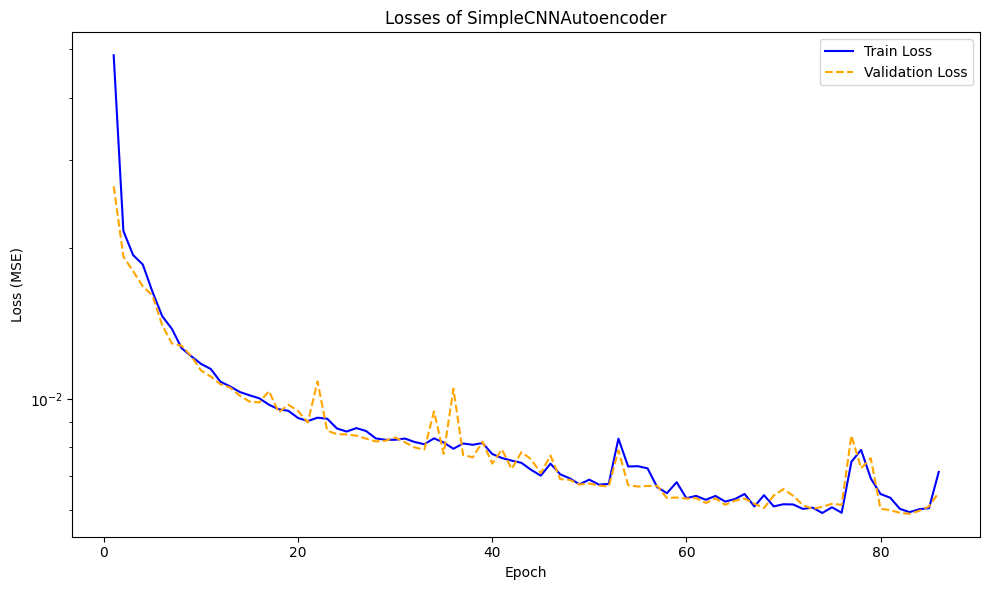

In [ ]:
draw_loss(experiment)

Training has stopped, but it seems like insted of overfitting there is a local pike. Early stopping mechanism should be upgrated.

In [ ]:
def need_stop(records, delta, size, threshold):
    if len(records) < size + 1:
        return False
    while len(records) > size + 1:
        records.pop(0)
    count = sum([records[i] - records[i+1] < 1e-6 for i in range(len(records)-1)])
    return count >= threshold * size

In [ ]:
def train(model, optimizer, criterion = nn.MSELoss(), max_epochs = 150, **params):
    max_epochs = 150
    model.train()

    history = []
    experiment = {
        "history": history,
        "max_epochs": max_epochs,
        "model": model,
    }
    experiment.update(params)

    loss_cycle = []
    for epoch in tqdm(range(max_epochs)):
        model.train()
        train_loss = 0.0
        for images in train_loader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images in val_loader:
                images = images.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, images).item()

        history.append({
            "epoch": epoch,
            "epoch_train_loss": train_loss / len(train_loader),
            "epoch_val_loss": val_loss / len(val_loader),
        })

        loss_cycle.append(val_loss / len(val_loader))
        if need_stop(loss_cycle, 1e-4, 8, 0.75):
            break

    return experiment

In [ ]:
experiments.pop()

'SimpleCNNAutoencoder'

In [ ]:
model = SimpleCNNAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.MSELoss()

experiment = train(model, optimizer, criterion, model_name="SimpleCNNAutoencoder_optimized", hyperparameters={"lr": lr, "weight_decay": weight_decay})

experiments[experiment['model_name']] = experiment
torch.save(model.state_dict(), f"/content/{experiment['model_name']}.pth")

  0%|          | 0/150 [00:00<?, ?it/s]

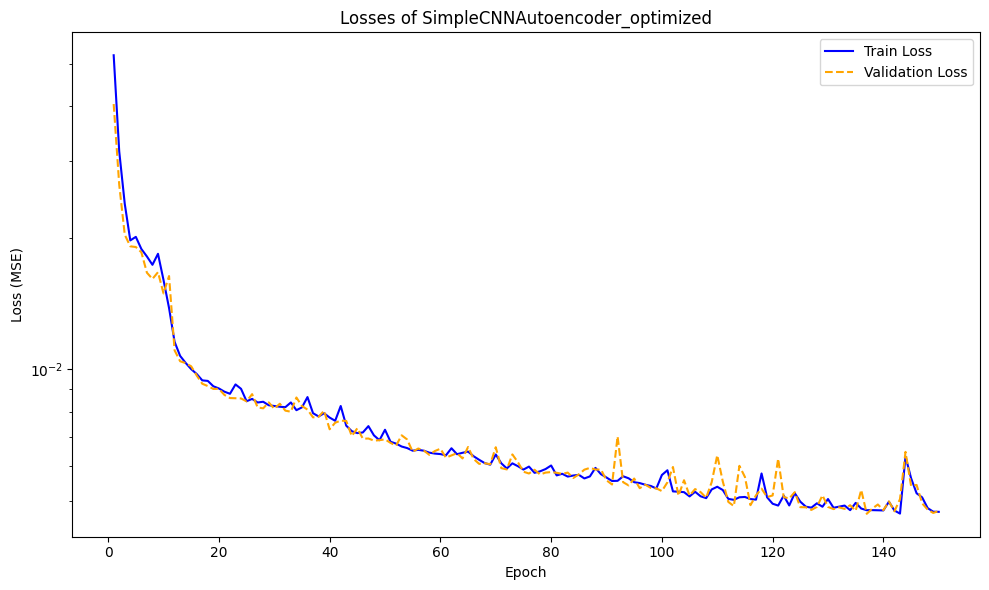

In [ ]:
draw_loss(experiment)

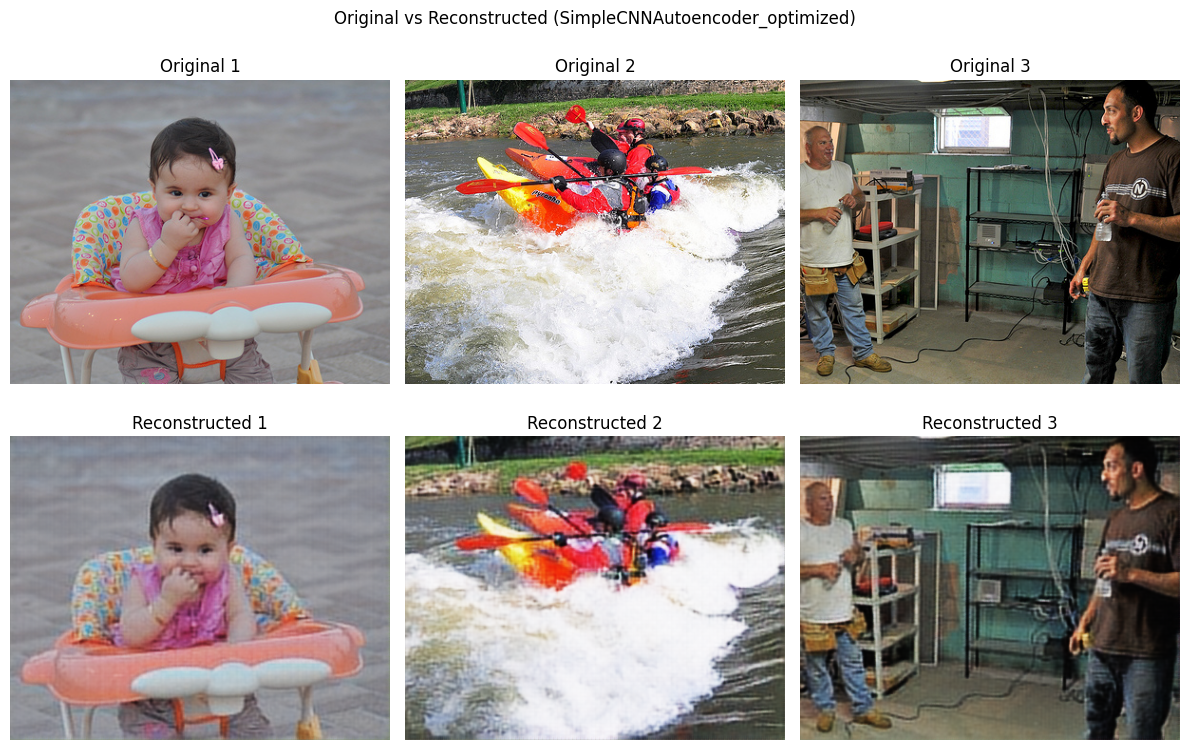

In [ ]:
draw_images(experiment, val_loader)

No visual difference.

In [ ]:
def compare_loss(experiments, draw_val=True):
    plt.figure(figsize=(10, 6))
    colors = ['blue', 'orange', 'green', 'red', 'pink', 'brown']

    for i, experiment in enumerate(experiments):
        train_losses = []
        val_losses = []

        for entry in experiment['history']:
            train_losses.append(entry["epoch_train_loss"])
            val_losses.append(entry["epoch_val_loss"])

        plt.plot(range(1, len(train_losses)+1), train_losses, label=f"{experiment['model_name']} (Train Loss)", color=colors[i])
        if draw_val:
            plt.plot(range(1, len(train_losses)+1), val_losses, label=f"{experiment['model_name']} (Val Loss)", linestyle='--', color=colors[i])

    plt.title("Losses of " + ', '.join([experiment['model_name'] for experiment in experiments]))
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

In [ ]:
ex = dict()
for exp in experiments:
    ex[exp['model_name']] = exp
experiments = ex

In [ ]:
compare_loss([experiments['SimpleCNNAutoencoder'], experiments['SimpleCNNAutoencoder_optimized']])

KeyError: 'SimpleCNNAutoencoder'

In the previous model I used `stride` as a way to reduce the amount of values on hidden layers. Other good strategy is a pooling.

In [ ]:
class PoolingCNNAutoencoder(nn.Module):
    def __init__(self):
        super(PoolingCNNAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # -> 16 x 400 x 320
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> 16 x 200 x 160
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # -> 32 x 200 x 160
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> 32 x 100 x 80
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # -> 64 x 100 x 80
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> 64 x 50 x 40
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # -> 128 x 50 x 40
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> 128 x 25 x 20
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 64 x 50 x 40
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 32 x 100 x 80
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 16 x 200 x 160
            nn.ReLU(),

            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 3 x 400 x 320
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def compress(self, image):
        return self.encoder(image)

    def decompress(self, embedding):
        return self.decoder(embedding)

In [ ]:
model = PoolingCNNAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.MSELoss()

experiment = train(model, optimizer, criterion, model_name="PoolingCNNAutoencoder", hyperparameters={"lr": lr, "weight_decay": weight_decay})

experiments[experiment['model_name']] = experiment
torch.save(model.state_dict(), f"/content/{experiment['model_name']}.pth")

  0%|          | 0/150 [00:00<?, ?it/s]

Started to overfit.

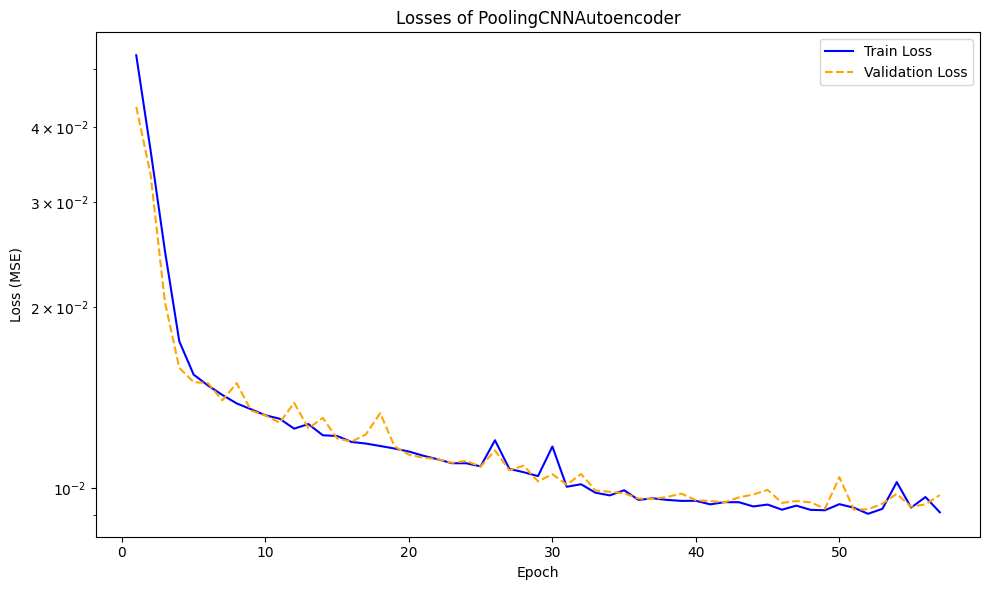

In [ ]:
draw_loss(experiment)

Seems worse.

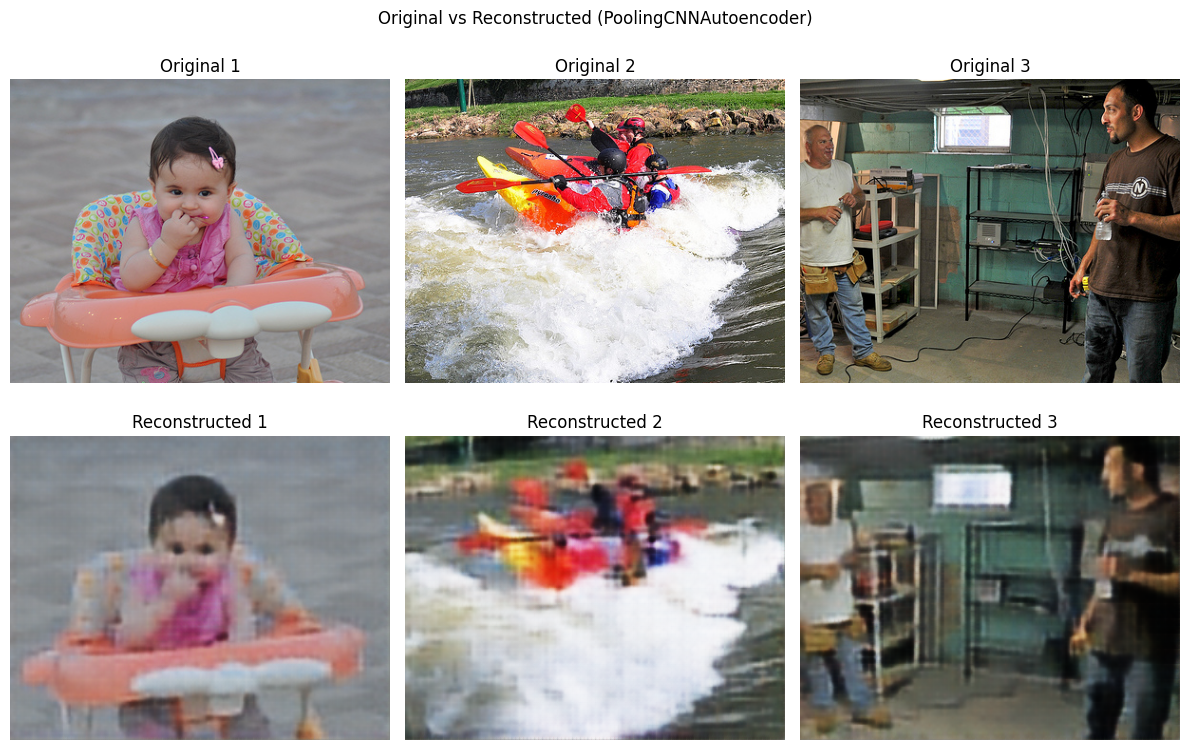

In [ ]:
draw_images(experiment, val_loader)

Definately worse.

Ok, before moving on to the linear layers inside the CNN and other enhancements I want to tune the pure CNN.

In [ ]:
class NormalizingCNNAutoencoder(nn.Module):
    def __init__(self):
        super(NormalizingCNNAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # -> 16 x 200 x 160
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # -> 32 x 100 x 80
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> 64 x 50 x 40
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # -> 128 x 25 x 20
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 64 x 50 x 40
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 32 x 100 x 80
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 16 x 200 x 160
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 3 x 400 x 320
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def compress(self, image):
        return self.encoder(image)

    def decompress(self, embedding):
        return self.decoder(embedding)

In [ ]:
model = NormalizingCNNAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.MSELoss()

experiment = train(model, optimizer, criterion, model_name="NormalizingCNNAutoencoder", hyperparameters={"lr": lr, "weight_decay": weight_decay})

experiments[experiment['model_name']] = experiment
torch.save(model.state_dict(), f"/content/{experiment['model_name']}.pth")

  0%|          | 0/150 [00:00<?, ?it/s]

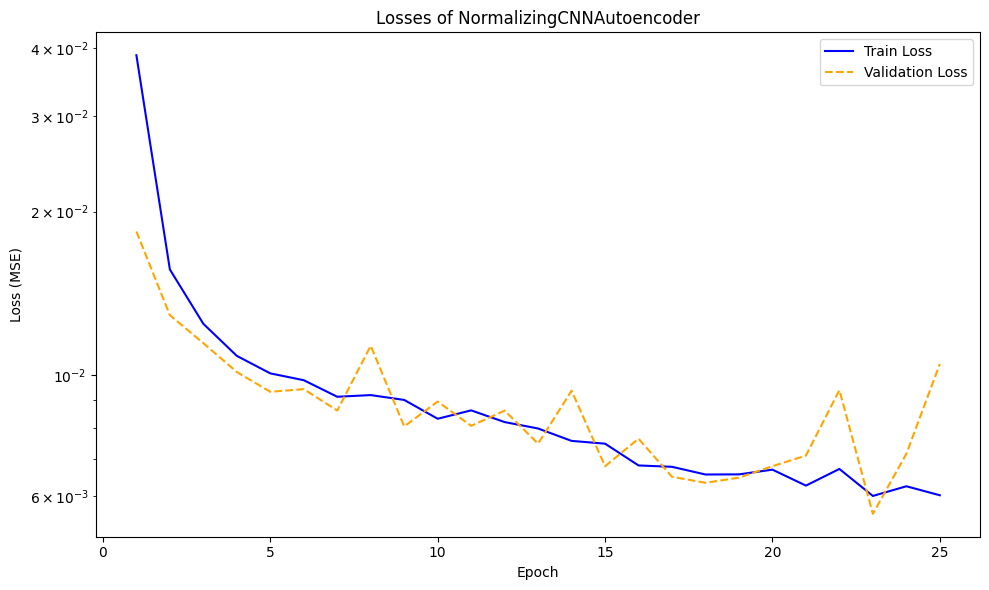

In [ ]:
draw_loss(experiment)

Oh wow! On 30-ish epoches we can see smaller loss than after 150 epochs on the previous models. But something unclear happens later. I will switch early stopping off to examine the situation.

In [ ]:
def train(model, optimizer, criterion = nn.MSELoss(), max_epochs = 150, early_stop_params=[1e-4, 8, 0.75], **params):
    max_epochs = 150
    model.train()

    history = []
    experiment = {
        "history": history,
        "max_epochs": max_epochs,
        "model": model,
    }
    experiment.update(params)

    loss_cycle = []
    for epoch in tqdm(range(max_epochs)):
        model.train()
        train_loss = 0.0
        for images in train_loader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images in val_loader:
                images = images.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, images).item()

        history.append({
            "epoch": epoch,
            "epoch_train_loss": train_loss / len(train_loader),
            "epoch_val_loss": val_loss / len(val_loader),
        })

        if early_stop_params:
            loss_cycle.append(val_loss / len(val_loader))
            if need_stop(loss_cycle, *early_stop_params):
                break

    return experiment

In [ ]:
model = NormalizingCNNAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.MSELoss()

experiment = train(model, optimizer, criterion, model_name="NormalizingCNNAutoencoder", early_stop_params=None, hyperparameters={"lr": lr, "weight_decay": weight_decay})

experiments[experiment['model_name']] = experiment
torch.save(model.state_dict(), f"/content/{experiment['model_name']}.pth")

  0%|          | 0/150 [00:00<?, ?it/s]